In [1]:
!pip install -q av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 50.2 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.video import r3d_18, R3D_18_Weights
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [3]:
import os

base = '/kaggle/input/datasets'

for user in os.listdir(base):
    user_path = os.path.join(base, user)
    for dataset in os.listdir(user_path):
        dataset_path = os.path.join(user_path, dataset)
        print(f"\n📁 {dataset_path}")
        for item in os.listdir(dataset_path):
            item_path = os.path.join(dataset_path, item)
            print(f"   ├── {item}")
            if os.path.isdir(item_path):
                for sub in os.listdir(item_path):
                    print(f"   │     ├── {sub}")


📁 /kaggle/input/datasets/rajasree25/actionvideos-upd
   ├── action_video
   │     ├── walking_4.mp4
   │     ├── brushhair_1.avi
   │     ├── brushhair_2.avi
   │     ├── walking_2.mp4
   │     ├── walking_7.mp4
   │     ├── run_6.mp4
   │     ├── punching_5.mp4
   │     ├── sit_4.mp4
   │     ├── hug_4.avi
   │     ├── fall_2.avi
   │     ├── walking_1.mp4
   │     ├── run_2.mp4
   │     ├── fi004.mp4
   │     ├── shaking_hands_4.mp4
   │     ├── shaking_hands_1.mp4
   │     ├── hug_3.avi
   │     ├── punching_3.mp4
   │     ├── fencing_3.avi
   │     ├── throw_4.mp4
   │     ├── shaking_hands_2.mp4
   │     ├── throw_8.mp4
   │     ├── throw_2.mp4
   │     ├── fencing_1.avi
   │     ├── fi005.mp4
   │     ├── punching_2.webm
   │     ├── run_4.mp4
   │     ├── hug_2.avi
   │     ├── hug_1.avi
   │     ├── throw_7.mp4
   │     ├── throw_1.mp4
   │     ├── sit_1.mp4
   │     ├── hug_5.avi
   │     ├── hug_6.avi
   │     ├── walking_5.mp4
   │     ├── throw_9.mp4
   │     ├── yoga_1.av

In [4]:
# ── EXACT PATHS based on your Kaggle structure ──
CHAIN_SNATCH_BASE  = '/kaggle/input/datasets/siddhantborude777/chain-snatching-and-anomaly-detection-dataset'
ACTION_VIDEOS_PATH = '/kaggle/input/datasets/yashtisahu/action-videos/Action Recognition Test Videos - Phase 3'

CHAIN_SNATCH_VIDEOS = os.path.join(CHAIN_SNATCH_BASE, 'chain_snatching_videos')
NORMAL_VIDEOS       = os.path.join(CHAIN_SNATCH_BASE, 'normal_videos')

# Model config
NUM_FRAMES    = 16
FRAME_SIZE    = 112
BATCH_SIZE    = 8
NUM_EPOCHS    = 20
LEARNING_RATE = 1e-4
NUM_CLASSES   = 2
MODEL_SAVE    = '/kaggle/working/best_model.pth'

print('Config loaded ✓')
print(f'Chain snatching path exists : {os.path.exists(CHAIN_SNATCH_VIDEOS)}')
print(f'Normal videos path exists   : {os.path.exists(NORMAL_VIDEOS)}')
print(f'Action videos path exists   : {os.path.exists(ACTION_VIDEOS_PATH)}')

Config loaded ✓
Chain snatching path exists : True
Normal videos path exists   : True
Action videos path exists   : True


In [5]:
# CELL 4 BUILD DATASET
VIDEO_EXTENSIONS = {'.mp4', '.avi', '.mov', '.mkv'}  # .webm removed

def get_videos_from_dir(directory, label):
    entries = []
    if not os.path.exists(directory):
        print(f'  ⚠ Not found: {directory}')
        return entries
    for root, _, files in os.walk(directory):
        for f in files:
            if os.path.splitext(f)[1].lower() in VIDEO_EXTENSIONS:
                entries.append({'path': os.path.join(root, f), 'label': label})
    print(f'  ✓ Found {len(entries)} videos in: {os.path.basename(directory)}')
    return entries

# ── ANOMALY (label=1) ──────────────────────────────────────
print('Loading ANOMALY videos...')
anomaly_data = []
anomaly_data += get_videos_from_dir(CHAIN_SNATCH_VIDEOS, 1)
anomaly_data += get_videos_from_dir(
    os.path.join(ACTION_VIDEOS_PATH, 'snatching'), 1)

# ── NORMAL (label=0) ───────────────────────────────────────
print('\nLoading NORMAL videos...')
normal_data = []
normal_data += get_videos_from_dir(NORMAL_VIDEOS, 0)
normal_data += get_videos_from_dir(
    os.path.join(ACTION_VIDEOS_PATH, 'normal_walking'), 0)

# Combine
all_data = normal_data + anomaly_data
df = pd.DataFrame(all_data).drop_duplicates(subset='path').reset_index(drop=True)

print(f'\nAnomaly : {(df["label"]==1).sum()}')
print(f'Normal  : {(df["label"]==0).sum()}')
print(f'Total   : {len(df)}')

Loading ANOMALY videos...
  ✓ Found 167 videos in: chain_snatching_videos
  ✓ Found 24 videos in: snatching

Loading NORMAL videos...
  ✓ Found 153 videos in: normal_videos
  ✓ Found 5 videos in: normal_walking

Anomaly : 191
Normal  : 158
Total   : 349


Balanced distribution:
label
Anomaly    191
Normal     191
Name: count, dtype: int64


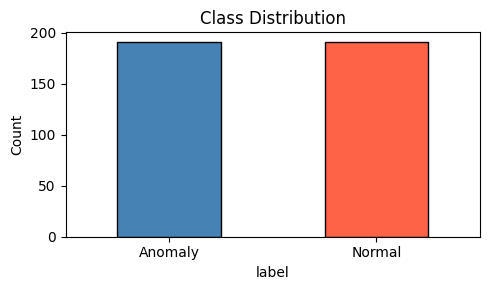

In [6]:
# CELL 5 BALANCE CLASSES
normal_df  = df[df['label'] == 0]
anomaly_df = df[df['label'] == 1]

if len(normal_df) > len(anomaly_df):
    anomaly_df = resample(anomaly_df, replace=True,
                          n_samples=len(normal_df), random_state=SEED)
else:
    normal_df = resample(normal_df, replace=True,
                         n_samples=len(anomaly_df), random_state=SEED)

df_balanced = pd.concat([normal_df, anomaly_df]).sample(
    frac=1, random_state=SEED).reset_index(drop=True)

print('Balanced distribution:')
print(df_balanced['label'].value_counts().rename({0:'Normal', 1:'Anomaly'}))

df_balanced['label'].map({0:'Normal',1:'Anomaly'}).value_counts().plot(
    kind='bar', color=['steelblue','tomato'], edgecolor='black', figsize=(5,3))
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
#CELL 6 TRAIN/VAL/TEST SPLIT
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.30,
    stratify=df_balanced['label'], random_state=SEED)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['label'], random_state=SEED)

print(f'Train : {len(train_df)}')
print(f'Val   : {len(val_df)}')
print(f'Test  : {len(test_df)}')

Train : 267
Val   : 57
Test  : 58


In [8]:
# CELL 7A PRE EXTRACT ALL FRAMES (run once)
import pickle

def preextract_frames(dataframe, num_frames=16, frame_size=112, save_path='/kaggle/working/frames_cache.pkl'):
    cache = {}
    print(f'Pre-extracting frames for {len(dataframe)} videos...')
    
    for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        path = row['path']
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total <= 0:
            cache[path] = np.zeros((num_frames, frame_size, frame_size, 3), dtype=np.uint8)
            cap.release()
            continue
            
        indices = np.linspace(0, total - 1, num_frames, dtype=int)
        frames = []
        
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (frame_size, frame_size))
                frames.append(frame)
            elif frames:
                frames.append(frames[-1])
            else:
                frames.append(np.zeros((frame_size, frame_size, 3), dtype=np.uint8))
        
        while len(frames) < num_frames:
            frames.append(frames[-1])
            
        cache[path] = np.array(frames[:num_frames], dtype=np.uint8)
        cap.release()
    
    with open(save_path, 'wb') as f:
        pickle.dump(cache, f)
    
    print(f'✓ Saved cache to {save_path}')
    return cache

# Pre-extract all frames once
all_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)
frames_cache = preextract_frames(all_df, NUM_FRAMES, FRAME_SIZE)
print(f'Total videos cached: {len(frames_cache)}')

Pre-extracting frames for 382 videos...


100%|██████████| 382/382 [46:17<00:00,  7.27s/it]


✓ Saved cache to /kaggle/working/frames_cache.pkl
Total videos cached: 298


In [9]:
# CELL 7B UPDATED DATASET USING CACHE
class VideoDataset(Dataset):
    def __init__(self, dataframe, frames_cache, augment=False):
        self.data   = dataframe.reset_index(drop=True)
        self.cache  = frames_cache
        self.augment = augment

        transform_list = []
        if augment:
            transform_list += [
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
            ]
        transform_list += [
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.43216, 0.394666, 0.37645],
                                  std=[0.22803,  0.22145,  0.216989])
        ]
        self.transform = transforms.Compose(transform_list)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row    = self.data.iloc[idx]
        label  = int(row['label'])
        frames = self.cache.get(row['path'])

        if frames is None:
            clip = torch.zeros(3, NUM_FRAMES, FRAME_SIZE, FRAME_SIZE)
            return clip, label

        tensors = [self.transform(Image.fromarray(f)) for f in frames]
        clip    = torch.stack(tensors, dim=1)  # (C, T, H, W)
        return clip, label

from PIL import Image

train_dataset = VideoDataset(train_df, frames_cache, augment=True)
val_dataset   = VideoDataset(val_df,   frames_cache, augment=False)
test_dataset  = VideoDataset(test_df,  frames_cache, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Sanity check
clip, lbl = train_dataset[0]
print(f'Clip shape : {clip.shape}')
print(f'Label      : {lbl}')

Clip shape : torch.Size([3, 16, 112, 112])
Label      : 0


In [10]:
# CELL 8 BUILD MODEL
def build_model(num_classes=2):
    model = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(NUM_CLASSES).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 226MB/s]


Total params    : 33,298,114
Trainable params: 33,298,114


In [11]:
# CELL 9 LOSS,OPTIMIZATION,SCEDULER
criterion = nn.CrossEntropyLoss()

backbone_params   = [p for n, p in model.named_parameters() if 'fc' not in n]
classifier_params = [p for n, p in model.named_parameters() if 'fc'     in n]

optimizer = optim.AdamW([
    {'params': backbone_params,   'lr': LEARNING_RATE * 0.1},
    {'params': classifier_params, 'lr': LEARNING_RATE}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('Optimizer & Scheduler ready ✓')

Optimizer & Scheduler ready ✓


In [12]:
# CELL 10 TRAINING LOOP
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clips, labels in tqdm(loader, desc='  Train', leave=False):
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * clips.size(0)
        correct    += (model(clips).argmax(1) == labels).sum().item()
        total      += clips.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for clips, labels in tqdm(loader, desc='  Eval ', leave=False):
            clips, labels = clips.to(DEVICE), labels.to(DEVICE)
            outputs = model(clips)
            loss    = criterion(outputs, labels)
            preds   = outputs.argmax(1)
            total_loss += loss.item() * clips.size(0)
            correct    += (preds == labels).sum().item()
            total      += clips.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc = 0.0

print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7}')
print('─' * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc        = train_one_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), MODEL_SAVE)
        flag = '  ← best'

    print(f'{epoch:5d} | {tr_loss:10.4f} | {tr_acc:9.4f} | {vl_loss:8.4f} | {vl_acc:7.4f}{flag}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch | Train Loss | Train Acc | Val Loss | Val Acc
───────────────────────────────────────────────────────


    1 |     0.6515 |    0.6367 |   0.5424 |  0.7544  ← best


    2 |     0.4672 |    0.8315 |   0.3321 |  0.9474  ← best


    3 |     0.3070 |    0.9064 |   0.1721 |  0.9649  ← best


    4 |     0.2073 |    0.9288 |   0.1172 |  0.9825  ← best


...

   16 |     0.0237 |    0.9888 |   0.1510 |  0.9474


   17 |     0.0122 |    1.0000 |   0.0265 |  0.9825


   18 |     0.0102 |    1.0000 |   0.0198 |  1.0000


   19 |     0.0332 |    0.9738 |   0.0292 |  0.9825


   20 |     0.0329 |    0.9888 |   0.0254 |  1.0000

Best Val Accuracy: 1.0000


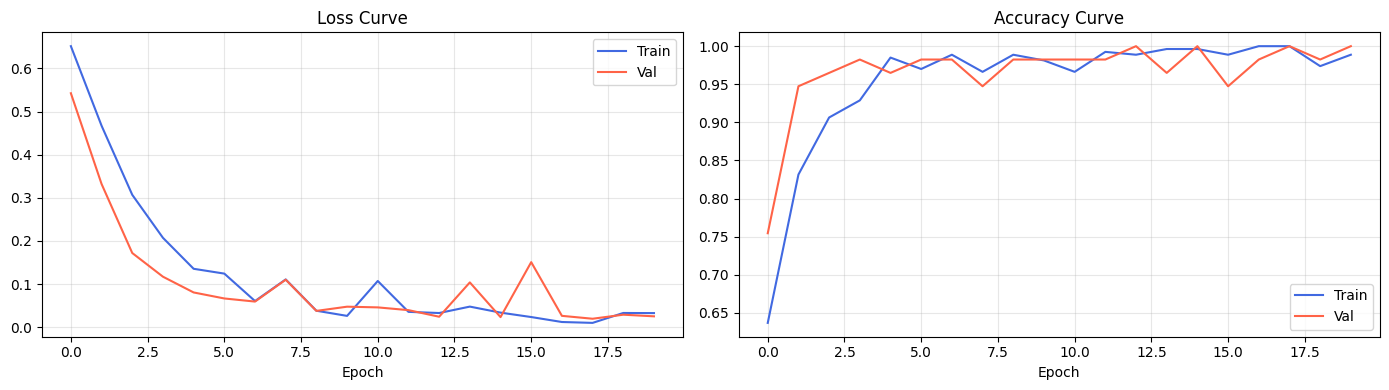

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train', color='royalblue')
axes[0].plot(history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', color='royalblue')
axes[1].plot(history['val_acc'],   label='Val',   color='tomato')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [14]:
model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
_, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

print(f'Test Accuracy: {test_acc:.4f}\n')
print(classification_report(
    test_labels, test_preds,
    target_names=['Normal', 'Chain Snatching']
))

Test Accuracy: 0.9828

                 precision    recall  f1-score   support

         Normal       0.97      1.00      0.98        29
Chain Snatching       1.00      0.97      0.98        29

       accuracy                           0.98        58
      macro avg       0.98      0.98      0.98        58
   weighted avg       0.98      0.98      0.98        58



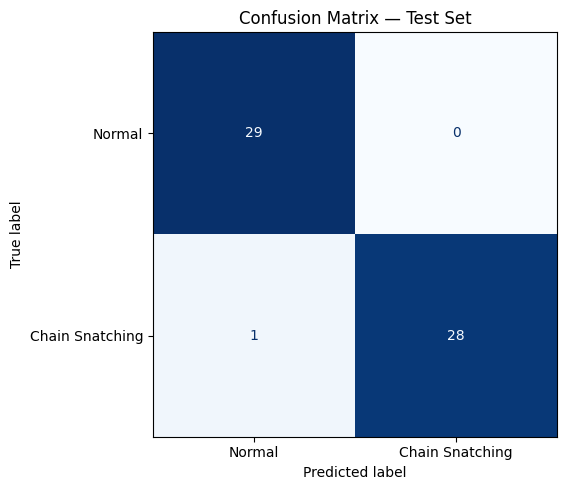

In [15]:
# CELL 13 CONFUSION MATRIX
cm   = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Chain Snatching'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

In [16]:
def predict_video(video_path, model):

    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((FRAME_SIZE, FRAME_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.43216, 0.394666, 0.37645],
                             std=[0.22803,  0.22145,  0.216989])
    ])

    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        return {
            "prediction": "Error",
            "confidence": "0%",
            "normal_prob": "0%",
            "snatch_prob": "0%"
        }

    indices = np.linspace(0, total - 1, NUM_FRAMES, dtype=int)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        elif frames:
            frames.append(frames[-1])
        else:
            frames.append(np.zeros((FRAME_SIZE, FRAME_SIZE, 3), dtype=np.uint8))

    cap.release()

    while len(frames) < NUM_FRAMES:
        frames.append(frames[-1])

    clip = torch.stack([transform(f) for f in frames], dim=1).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(clip), dim=1)[0].cpu().numpy()

    labels = ['Normal', 'Chain Snatching']
    prediction = labels[np.argmax(probs)]
    confidence = float(np.max(probs))

    return {
        "prediction": prediction,
        "confidence": f"{confidence:.2%}",
        "normal_prob": f"{probs[0]:.2%}",
        "snatch_prob": f"{probs[1]:.2%}"
    }

In [17]:
import pandas as pd
import os

# Auto find videos
normal_base = NORMAL_VIDEOS
chain_base  = CHAIN_SNATCH_VIDEOS

VIDEO_EXTENSIONS = {'.mp4', '.avi', '.mov', '.mkv'}

def find_videos(base_path):
    found = []
    for root, _, files in os.walk(base_path):
        for f in files:
            if os.path.splitext(f)[1].lower() in VIDEO_EXTENSIONS:
                found.append(os.path.join(root, f))
    return found

normal_videos = find_videos(normal_base)
chain_videos  = find_videos(chain_base)

test_videos = [(p, 'Normal') for p in normal_videos] + \
              [(p, 'Chain Snatching') for p in chain_videos]

results_list = []

print(f'{"Video":<40} | {"True":<15} | {"Predicted":<18} | {"Conf %":<8} | OK')
print('-'*95)

for path, true_label in test_videos:
    result = predict_video(path, model)

    predicted = result['prediction']
    conf      = result['confidence']
    correct   = 'YES' if true_label == predicted else 'NO'

    filename = os.path.basename(path)

    print(f'{filename:<40} | {true_label:<15} | {predicted:<18} | {conf:<8} | {correct}')

    results_list.append({
        "Video": filename,
        "Full Path": path,
        "True Label": true_label,
        "Predicted": predicted,
        "Confidence (%)": conf,
        "Normal Prob (%)": result['normal_prob'],
        "Snatch Prob (%)": result['snatch_prob'],
        "Correct?": correct
    })

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

# Save Excel file
excel_path = "/kaggle/working/video_predictions.xlsx"
results_df.to_excel(excel_path, index=False)

print("\n✅ Excel file saved at:", excel_path)

Video                                    | True            | Predicted          | Conf %   | OK
-----------------------------------------------------------------------------------------------
Object_5.mp4                             | Normal          | Normal             | 96.09%   | YES
Object.mp4                               | Normal          | Normal             | 99.64%   | YES
Object_7.mp4                             | Normal          | Normal             | 99.47%   | YES
Object_3.mp4                             | Normal          | Normal             | 98.52%   | YES
Object_4.mp4                             | Normal          | Normal             | 99.98%   | YES
Object_6.mp4                             | Normal          | Normal             | 89.59%   | YES
Object_2.mp4                             | Normal          | Normal             | 99.52%   | YES
Walking_While_Using_Phone_119_.mp4       | Normal          | Normal             | 99.75%   | YES
Walking_10_.mp4                 